In [ ]:
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import cv2
from pathlib import Path
from PIL import Image
from scipy.stats import entropy
from sklearn.manifold import TSNE
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score
)
from sklearn.preprocessing import label_binarize
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

print(f'TensorFlow : {tf.__version__}')
print(f'GPU        : {len(tf.config.list_physical_devices("GPU")) > 0}')

2026-02-25 16:28:57.971906: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772036938.349465      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772036938.462581      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772036939.519497      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772036939.519536      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772036939.519538      55 computation_placer.cc:177] computation placer alr

TensorFlow : 2.19.0
GPU        : True


1.2 Folder Structure

In [ ]:
DIRS = [
    'data/raw', 'data/processed',
    'outputs/figures', 'outputs/metrics',
    'models'
]
for d in DIRS:
    Path(d).mkdir(parents=True, exist_ok=True)

print('Folder structure created:')
for d in DIRS:
    print(f'  {d}/')

Folder structure created:
  data/raw/
  data/processed/
  outputs/figures/
  outputs/metrics/
  models/


1.3 Download Dataset

In [ ]:
DATASET_URL = 'https://www.kaggle.com/api/v1/datasets/download/saifurrahmanshatil/multiclass-chest-xray-disease-dataset'

!curl -L '{DATASET_URL}' -o data/raw/archive.zip

with zipfile.ZipFile('data/raw/archive.zip', 'r') as z:
    z.extractall('data/raw/')

print('Dataset extracted.')

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 2108M  100 2108M    0     0   116M      0  0:00:18  0:00:18 --:--:--  128M114M      0  0:00:18  0:00:17  0:00:01  122M
Dataset extracted.


1.4 Load Classes & Verify Integrity

In [ ]:
VALID_EXT = {'.jpg', '.jpeg', '.png'}

def build_df_from_dir(split_dir):
    records = []
    for class_dir in sorted(Path(split_dir).iterdir()):
        if not class_dir.is_dir():
            continue
        for img_path in class_dir.iterdir():
            if img_path.suffix.lower() in VALID_EXT:
                records.append({'path': str(img_path), 'label': class_dir.name})
    return pd.DataFrame(records)

BASE = 'data/raw/chest_xray'
train_df = build_df_from_dir(f'{BASE}/train')
val_df   = build_df_from_dir(f'{BASE}/val')
test_df  = build_df_from_dir(f'{BASE}/test')

CLASS_NAMES = sorted(train_df['label'].unique().tolist())
CLASS_TO_IDX = {cls: i for i, cls in enumerate(CLASS_NAMES)}
NUM_CLASSES = len(CLASS_NAMES)

for df in [train_df, val_df, test_df]:
    df['label_idx'] = df['label'].map(CLASS_TO_IDX)

class_inventory = {cls: train_df[train_df['label']==cls]['path'].tolist() for cls in CLASS_NAMES}

corrupted = []
for cls in CLASS_NAMES:
    for p in class_inventory[cls]:
        try: Image.open(p).verify()
        except: corrupted.append(p)

print(f'Classes        : {CLASS_NAMES}')
print(f'Corrupted      : {len(corrupted)}')
print(f'Train/Val/Test : {len(train_df)}/{len(val_df)}/{len(test_df)}')
for cls in CLASS_NAMES:
    print(f'  {cls}: {len(class_inventory[cls])} train images')

Classes        : ['COVID', 'Lung_Opacity', 'NORMAL', 'PNEUMONIA', 'TURBERCULOSIS']
Corrupted      : 0
Train/Val/Test : 15794/107/861
  COVID: 4076 train images
  Lung_Opacity: 5852 train images
  NORMAL: 1341 train images
  PNEUMONIA: 3875 train images
  TURBERCULOSIS: 650 train images


Stage 2: Research-Grade EDA

2.1 Class Imbalance Severity Analysis

In [ ]:
CLASS_COUNTS = np.array([len(class_inventory[c]) for c in CLASS_NAMES])
proportions = CLASS_COUNTS / CLASS_COUNTS.sum()
shannon_entropy = entropy(proportions, base=2)
max_entropy = np.log2(NUM_CLASSES)
imbalance_ratio = CLASS_COUNTS.max() / CLASS_COUNTS.min()

print(f'Total images       : {CLASS_COUNTS.sum()}')
print(f'Imbalance Ratio    : {imbalance_ratio:.2f}')
print(f'Shannon Entropy    : {shannon_entropy:.4f} / {max_entropy:.4f} (max)')
print(f'Normalised Entropy : {shannon_entropy/max_entropy:.4f}  (1.0 = perfectly balanced)')

Total images       : 15794
Imbalance Ratio    : 9.00
Shannon Entropy    : 2.0239 / 2.3219 (max)
Normalised Entropy : 0.8716  (1.0 = perfectly balanced)


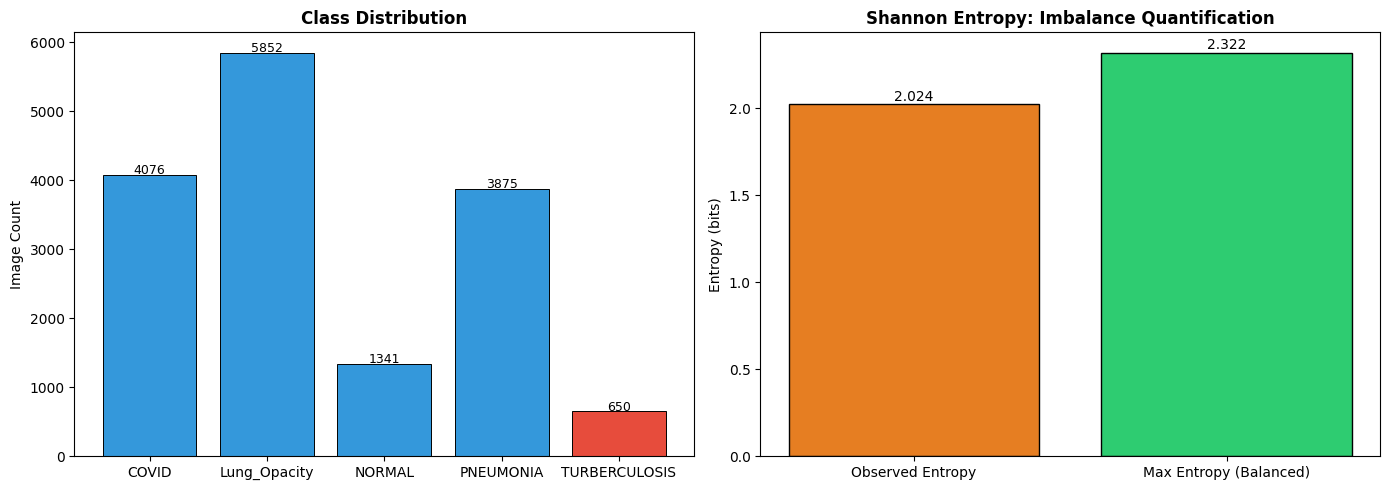

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#e74c3c' if c == CLASS_COUNTS.min() else '#3498db' for c in CLASS_COUNTS]
axes[0].bar(CLASS_NAMES, CLASS_COUNTS, color=colors, edgecolor='black', linewidth=0.7)
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_ylabel('Image Count')
for i, v in enumerate(CLASS_COUNTS):
    axes[0].text(i, v + 10, str(v), ha='center', fontsize=9)

axes[1].bar(['Observed Entropy', 'Max Entropy (Balanced)'],
            [shannon_entropy, max_entropy], color=['#e67e22', '#2ecc71'], edgecolor='black')
axes[1].set_title('Shannon Entropy: Imbalance Quantification', fontweight='bold')
axes[1].set_ylabel('Entropy (bits)')
axes[1].text(0, shannon_entropy+0.02, f'{shannon_entropy:.3f}', ha='center')
axes[1].text(1, max_entropy+0.02, f'{max_entropy:.3f}', ha='center')

plt.tight_layout()
plt.savefig('outputs/figures/2a_class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()

2.2 Image Quality & Artifact Analysis

In [ ]:
def compute_image_stats(img_path):
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if img is None: return None
    return img.mean(), img.std(), cv2.Laplacian(img, cv2.CV_64F).var()

quality_records = []
for cls in CLASS_NAMES:
    for p in class_inventory[cls][:150]:
        s = compute_image_stats(p)
        if s:
            quality_records.append({'class': cls, 'brightness': s[0], 'contrast': s[1], 'sharpness': s[2]})

quality_df = pd.DataFrame(quality_records)
print(quality_df.groupby('class')[['brightness','contrast','sharpness']].mean().round(2))

               brightness  contrast  sharpness
class                                         
COVID              137.73     54.53     119.25
Lung_Opacity       125.00     57.45     130.87
NORMAL             122.94     62.01     155.14
PNEUMONIA          124.32     56.77     134.87
TURBERCULOSIS      127.16     53.40      31.05


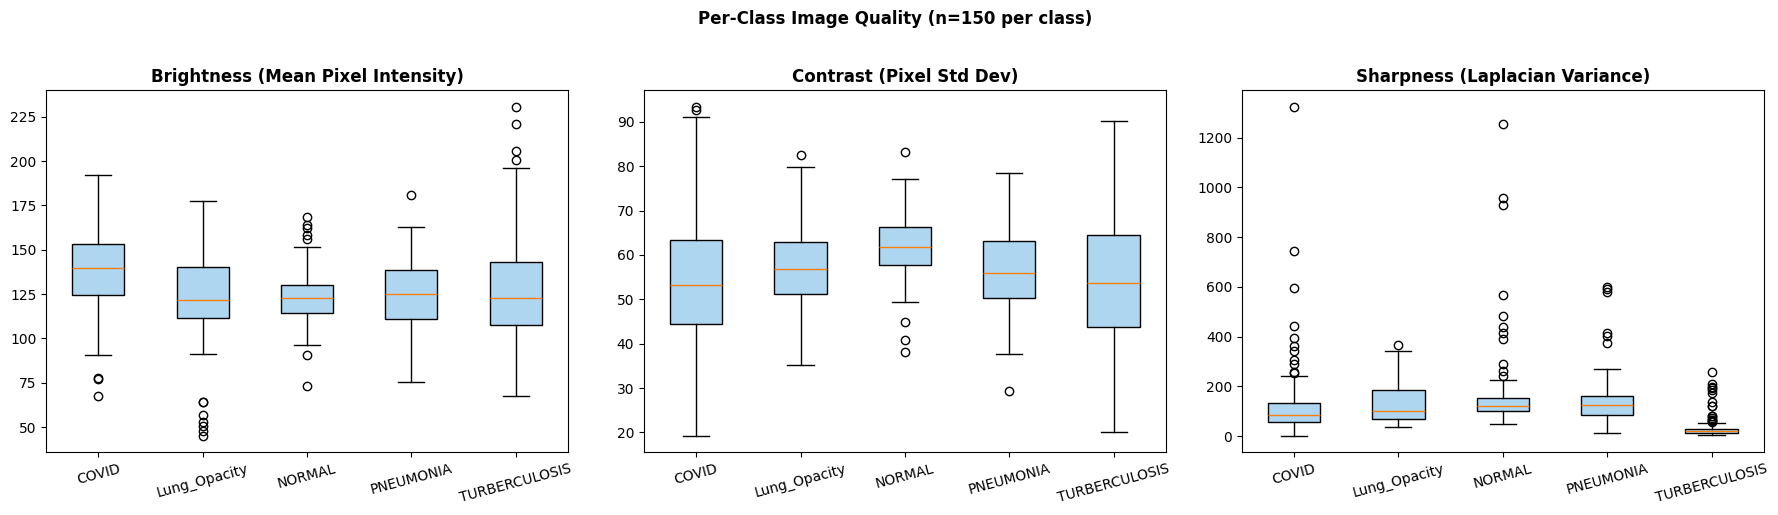

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, metric, title in zip(axes,
    ['brightness','contrast','sharpness'],
    ['Brightness (Mean Pixel Intensity)','Contrast (Pixel Std Dev)','Sharpness (Laplacian Variance)']):
    data = [quality_df[quality_df['class']==cls][metric].values for cls in CLASS_NAMES]
    bp = ax.boxplot(data, tick_labels=CLASS_NAMES, patch_artist=True)
    for patch in bp['boxes']: patch.set_facecolor('#aed6f1')
    ax.set_title(title, fontweight='bold')
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Per-Class Image Quality (n=150 per class)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/figures/2b_image_quality.png', dpi=150, bbox_inches='tight')
plt.show()

2.3 Visual & Histogram Proof That CLAHE Is Needed

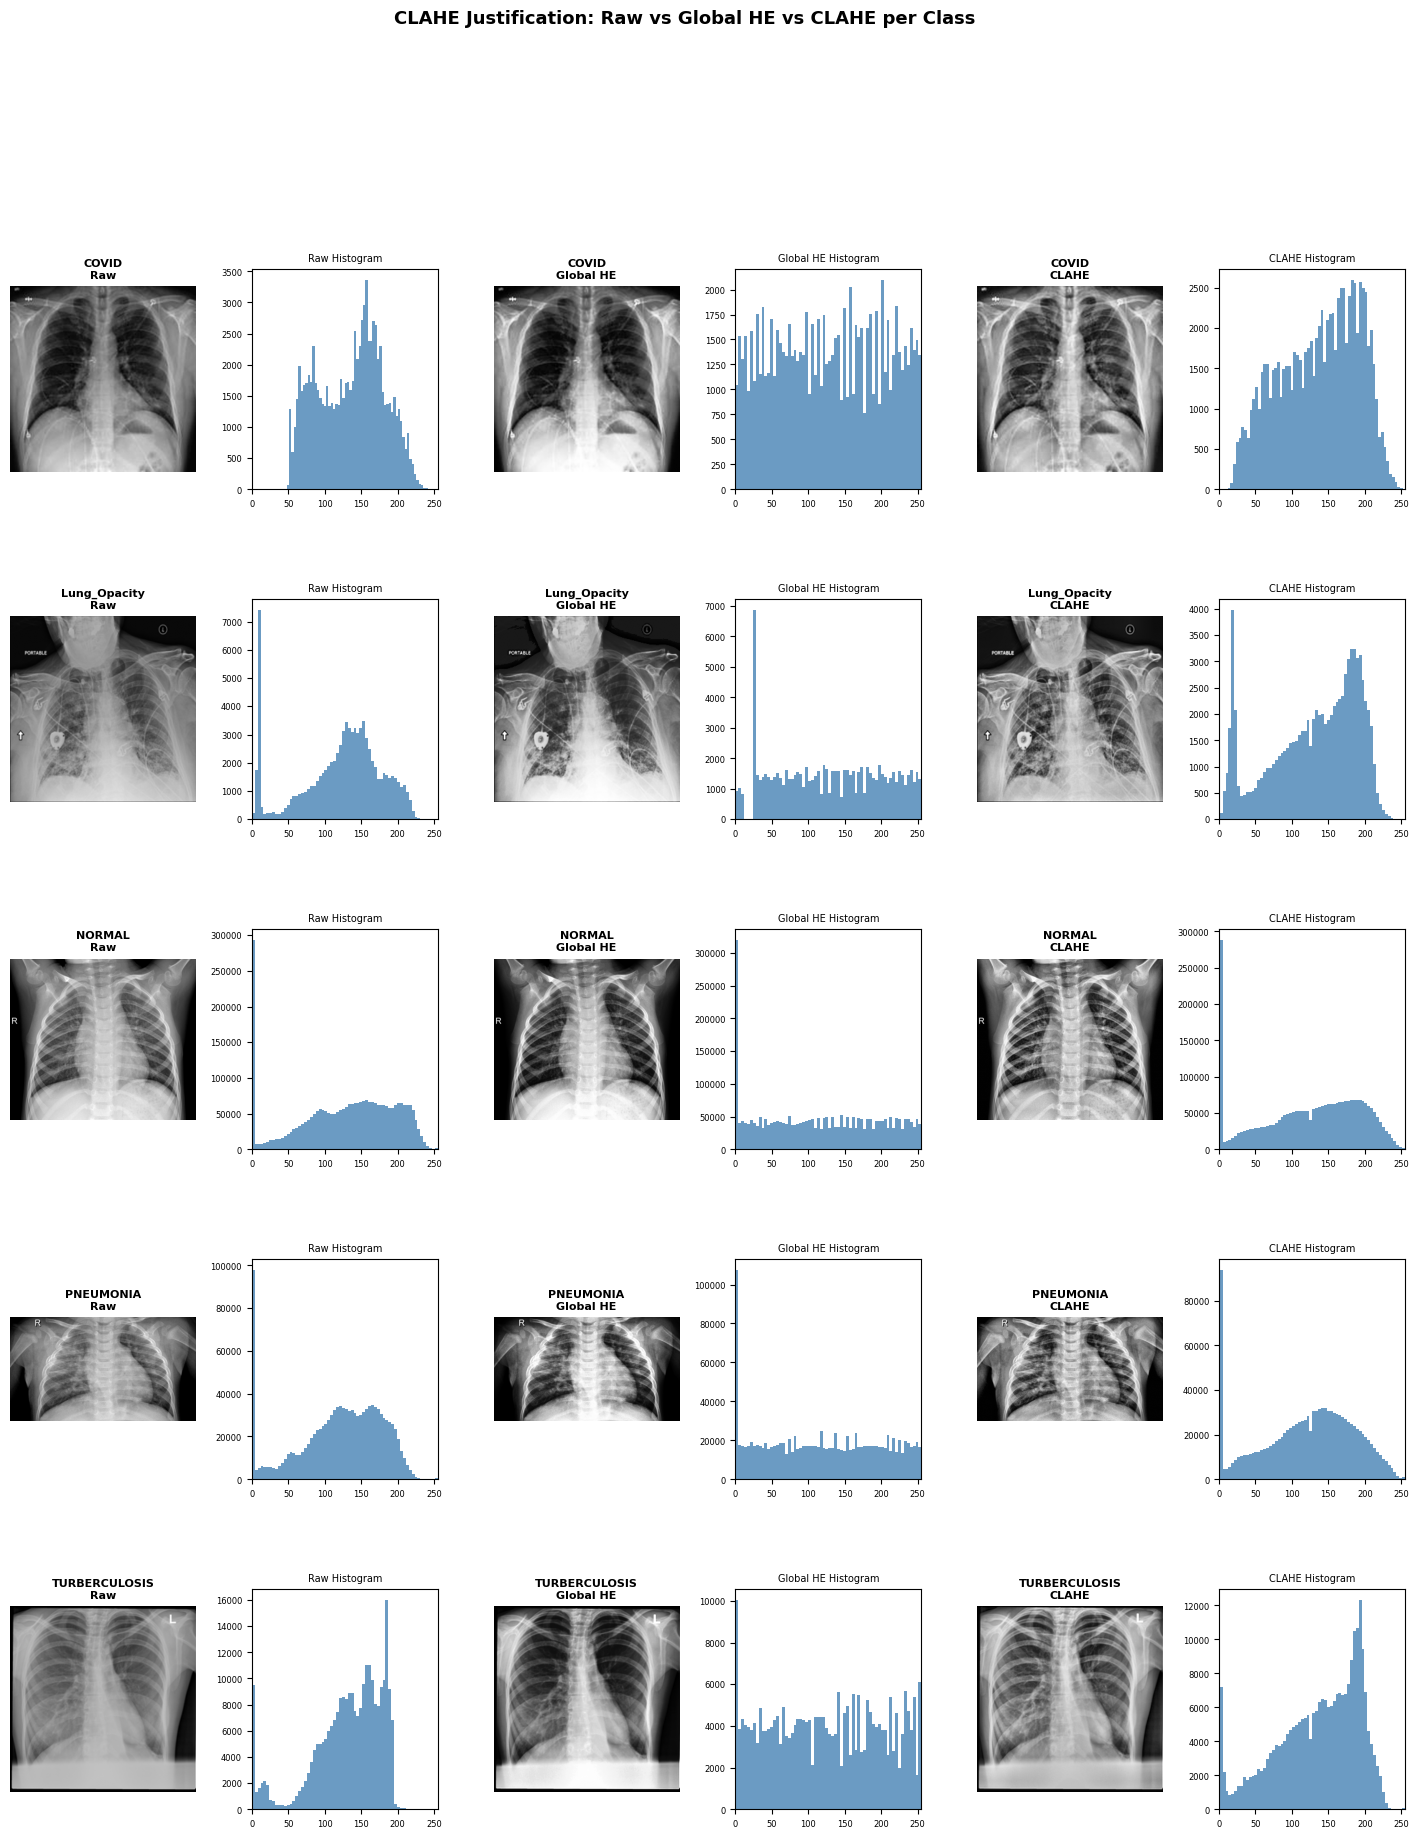

In [ ]:
def apply_clahe(img, clip=2.0, tile=(8,8)):
    return cv2.createCLAHE(clipLimit=clip, tileGridSize=tile).apply(img)

sample_per_class = {cls: class_inventory[cls][0] for cls in CLASS_NAMES}

fig = plt.figure(figsize=(18, len(CLASS_NAMES)*4))
gs = gridspec.GridSpec(len(CLASS_NAMES), 6, figure=fig, hspace=0.5, wspace=0.3)

for row, cls in enumerate(CLASS_NAMES):
    img = cv2.imread(str(sample_per_class[cls]), cv2.IMREAD_GRAYSCALE)
    versions = [img, cv2.equalizeHist(img), apply_clahe(img)]
    labels   = ['Raw', 'Global HE', 'CLAHE']

    for col, (im, lbl) in enumerate(zip(versions, labels)):
        ax_img = fig.add_subplot(gs[row, col*2])
        ax_img.imshow(im, cmap='gray'); ax_img.axis('off')
        ax_img.set_title(f'{cls}\n{lbl}', fontsize=8, fontweight='bold')

        ax_h = fig.add_subplot(gs[row, col*2+1])
        ax_h.hist(im.ravel(), bins=64, color='steelblue', alpha=0.8)
        ax_h.set_title(f'{lbl} Histogram', fontsize=7)
        ax_h.set_xlim([0,255]); ax_h.tick_params(labelsize=6)

plt.suptitle('CLAHE Justification: Raw vs Global HE vs CLAHE per Class', fontweight='bold', fontsize=13, y=1.01)
plt.savefig('outputs/figures/2c_clahe_justification.png', dpi=150, bbox_inches='tight')
plt.show()

2.4 Why Standard Augmentation Is Anatomically Invalid for Chest X-Rays

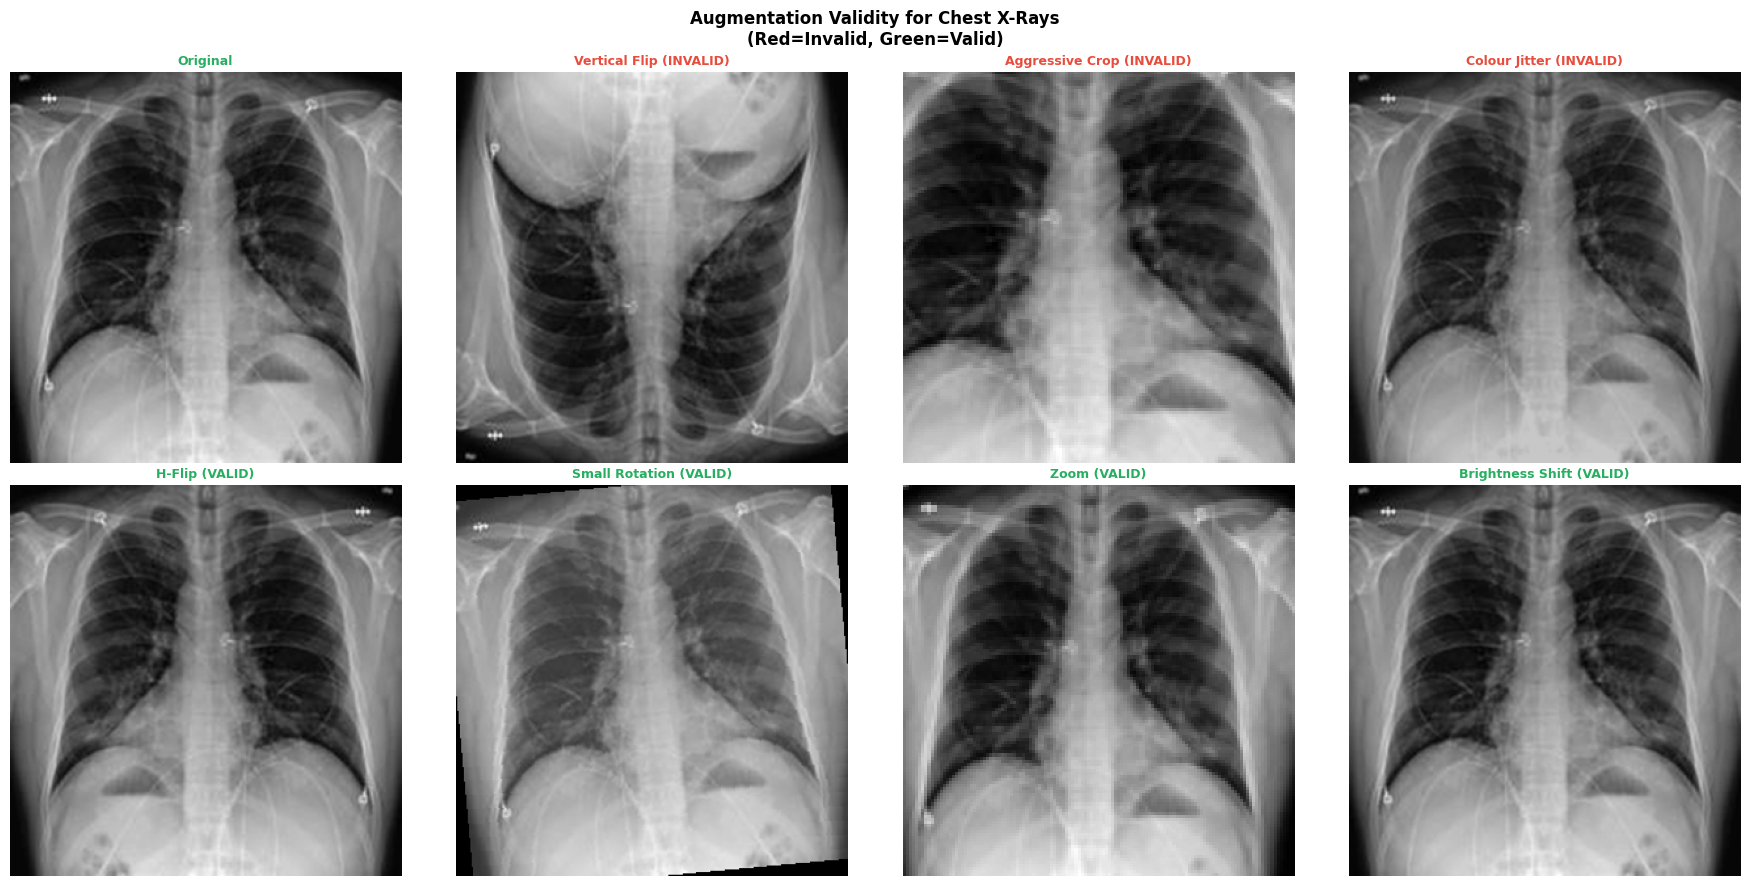

In [ ]:
import torchvision.transforms as T
from PIL import Image as PILImage

raw = cv2.imread(str(class_inventory[CLASS_NAMES[0]][0]), cv2.IMREAD_GRAYSCALE)
raw_pil = PILImage.fromarray(raw).convert('RGB')

augmentations = {
    'Original':                 T.Compose([T.Grayscale()]),
    'Vertical Flip (INVALID)':  T.Compose([T.Grayscale(), T.RandomVerticalFlip(p=1.0)]),
    'Aggressive Crop (INVALID)':T.Compose([T.Grayscale(), T.RandomResizedCrop(128, scale=(0.4,0.6))]),
    'Colour Jitter (INVALID)':  T.Compose([T.ColorJitter(brightness=0.8,contrast=0.8,saturation=0.8,hue=0.4)]),
    'H-Flip (VALID)':           T.Compose([T.Grayscale(), T.RandomHorizontalFlip(p=1.0)]),
    'Small Rotation (VALID)':   T.Compose([T.Grayscale(), T.RandomRotation(10)]),
    'Zoom (VALID)':             T.Compose([T.Grayscale(), T.RandomResizedCrop(128, scale=(0.85,1.0))]),
    'Brightness Shift (VALID)': T.Compose([T.Grayscale(), T.ColorJitter(brightness=0.15)])
}

fig, axes = plt.subplots(2, 4, figsize=(18,9))
for ax, (name, aug) in zip(axes.flatten(), augmentations.items()):
    ax.imshow(aug(raw_pil), cmap='gray')
    ax.set_title(name, fontweight='bold',
                 color='#e74c3c' if 'INVALID' in name else '#27ae60', fontsize=9)
    ax.axis('off')

plt.suptitle('Augmentation Validity for Chest X-Rays\n(Red=Invalid, Green=Valid)', fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/figures/2d_augmentation_validity.png', dpi=150, bbox_inches='tight')
plt.show()

2.5 t-SNE Feature Space Visualisation (Raw vs CLAHE)

In [ ]:
N_SAMPLE, TSNE_SIZE = 80, 64
raw_px, clahe_px, tsne_lbls = [], [], []

for cls in CLASS_NAMES:
    for p in class_inventory[cls][:N_SAMPLE]:
        img = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
        if img is None: continue
        r = cv2.resize(img, (TSNE_SIZE, TSNE_SIZE))
        raw_px.append(r.flatten())
        clahe_px.append(apply_clahe(r).flatten())
        tsne_lbls.append(cls)

raw_px = np.array(raw_px) / 255.0
clahe_px = np.array(clahe_px) / 255.0
tsne_lbls = np.array(tsne_lbls)

raw_2d   = TSNE(n_components=2, random_state=SEED, perplexity=30, max_iter=1000).fit_transform(raw_px)
clahe_2d = TSNE(n_components=2, random_state=SEED, perplexity=30, max_iter=1000).fit_transform(clahe_px)
print('t-SNE complete.')

t-SNE complete.


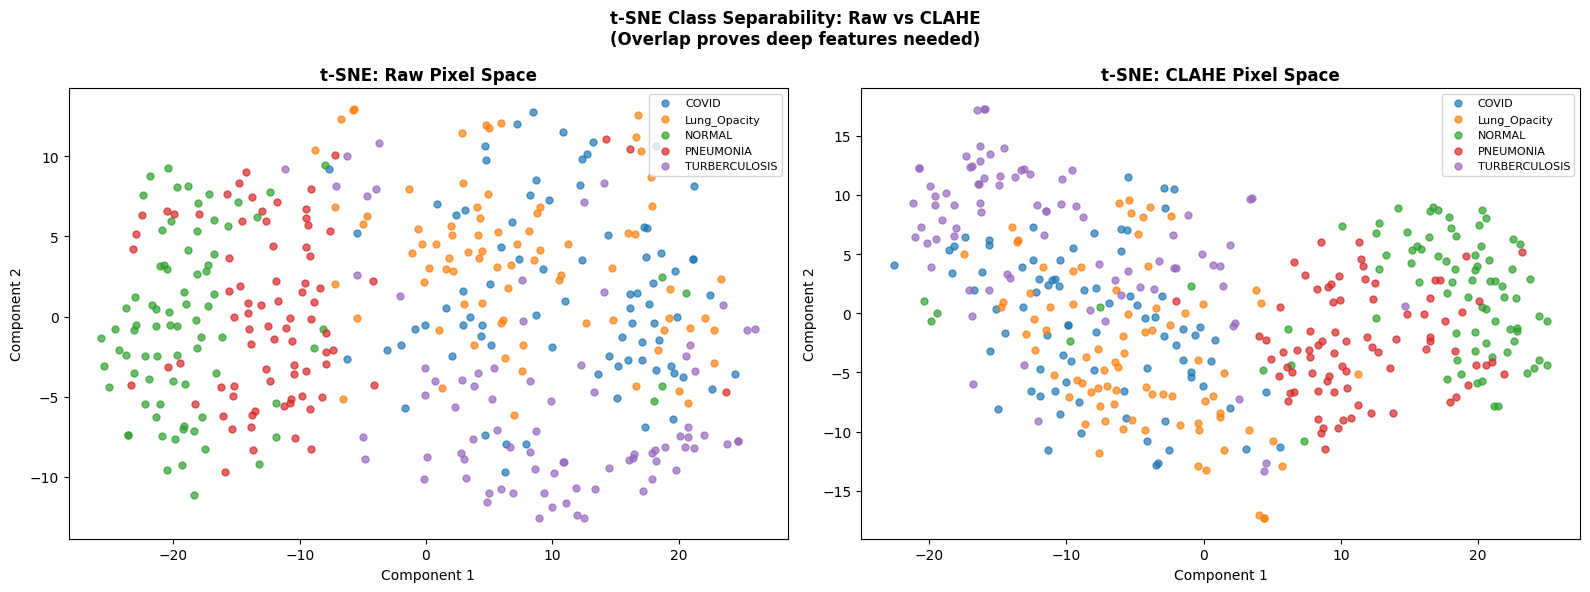

In [ ]:
palette = sns.color_palette('tab10', NUM_CLASSES)
color_map = {cls: palette[i] for i, cls in enumerate(CLASS_NAMES)}

fig, axes = plt.subplots(1, 2, figsize=(16,6))
for ax, emb, title in zip(axes, [raw_2d, clahe_2d], ['Raw Pixel Space','CLAHE Pixel Space']):
    for cls in CLASS_NAMES:
        m = tsne_lbls == cls
        ax.scatter(emb[m,0], emb[m,1], label=cls, color=color_map[cls], alpha=0.7, s=25)
    ax.set_title(f't-SNE: {title}', fontweight='bold')
    ax.set_xlabel('Component 1'); ax.set_ylabel('Component 2')
    ax.legend(fontsize=8)

plt.suptitle('t-SNE Class Separability: Raw vs CLAHE\n(Overlap proves deep features needed)', fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/figures/2e_tsne.png', dpi=150, bbox_inches='tight')
plt.show()

Stage 3: Preprocessing Pipeline

3.1 Constants & CLAHE Preprocess Function

In [ ]:
IMG_SIZE   = 128
BATCH_SIZE = 32

def preprocess_image(img_path):
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8)).apply(img)
    img = np.stack([img, img, img], axis=-1).astype(np.float32) / 255.0
    return img

print(f'Input shape : ({IMG_SIZE}, {IMG_SIZE}, 3)')

Input shape : (128, 128, 3)


3.2 Save Split CSVs for Reproducibility

In [ ]:
train_df.to_csv('outputs/metrics/train_split.csv', index=False)
val_df.to_csv('outputs/metrics/val_split.csv', index=False)
test_df.to_csv('outputs/metrics/test_split.csv', index=False)
print('Split CSVs saved.')
print(train_df['label'].value_counts())

Split CSVs saved.
label
Lung_Opacity     5852
COVID            4076
PNEUMONIA        3875
NORMAL           1341
TURBERCULOSIS     650
Name: count, dtype: int64


Stage 4: Data-Driven Augmentation Strategy

### 4.1 IR-Based Augmentation Multipliers

In [ ]:
train_counts = train_df['label'].value_counts()
max_count = train_counts.max()
aug_multipliers = {cls: max(1, round(max_count / train_counts[cls])) for cls in CLASS_NAMES}

print('IR-Based Augmentation Multipliers:')
for cls, mult in aug_multipliers.items():
    print(f'  {cls}: x{mult}  (count: {train_counts[cls]})')

IR-Based Augmentation Multipliers:
  COVID: x1  (count: 4076)
  Lung_Opacity: x1  (count: 5852)
  NORMAL: x4  (count: 1341)
  PNEUMONIA: x2  (count: 3875)
  TURBERCULOSIS: x9  (count: 650)


### 4.2 Build tf.data Pipelines

In [ ]:
# Define layers once outside the function
_random_rotation = keras.layers.RandomRotation(factor=0.05)
_random_zoom = keras.layers.RandomZoom(height_factor=(-0.1, 0.1))

def augment_image(image):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.15)
    image = _random_rotation(image, training=True)
    image = _random_zoom(image, training=True)
    return tf.clip_by_value(image, 0.0, 1.0)

def load_and_preprocess(path, label):
    img = preprocess_image(path.numpy().decode())
    return img, label

def tf_load(path, label):
    img, lbl = tf.py_function(load_and_preprocess, [path, label], [tf.float32, tf.int32])
    img.set_shape([IMG_SIZE, IMG_SIZE, 3])
    lbl.set_shape([])
    lbl_onehot = tf.one_hot(lbl, NUM_CLASSES)
    return img, lbl_onehot

def build_augmented_train_df():
    rows = []
    for _, row in train_df.iterrows():
        for _ in range(aug_multipliers.get(row['label'], 1)):
            rows.append(row)
    return pd.DataFrame(rows).sample(frac=1, random_state=SEED).reset_index(drop=True)

aug_train_df = build_augmented_train_df()

def make_dataset(df, augment=False, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices(
        (df['path'].values, df['label_idx'].values.astype(np.int32))
    )
    if shuffle:
        ds = ds.shuffle(buffer_size=len(df), seed=SEED)
    ds = ds.map(tf_load, num_parallel_calls=tf.data.AUTOTUNE)
    if augment:
        ds = ds.map(lambda x, y: (augment_image(x), y), num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds = make_dataset(aug_train_df, augment=True, shuffle=True)
val_ds   = make_dataset(val_df)
test_ds  = make_dataset(test_df)

print(f'Augmented train : {len(aug_train_df)} | Val : {len(val_df)} | Test : {len(test_df)}')

I0000 00:00:1772037054.113724      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1772037054.119953      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Augmented train : 28892 | Val : 107 | Test : 861


Stage 5: CNN Architecture with Channel Attention

5.1 Channel Attention Block

In [ ]:
def channel_attention(x, reduction=16):
    c = x.shape[-1]
    s = layers.GlobalAveragePooling2D()(x)
    s = layers.Dense(c // reduction, activation='relu')(s)
    s = layers.Dense(c, activation='sigmoid')(s)
    s = layers.Reshape((1, 1, c))(s)
    return layers.Multiply()([x, s])

5.2 Conv Block

In [ ]:
def conv_block(x, filters):
    x = layers.Conv2D(filters, 3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(filters, 3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.SpatialDropout2D(0.3)(x)
    return x

5.3 Build Full Model

In [ ]:
def build_model(num_classes):
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = conv_block(inputs, 32)
    x = conv_block(x, 64)
    x = conv_block(x, 128)
    x = conv_block(x, 256)
    x = channel_attention(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return keras.Model(inputs, outputs, name='ChestXRayCNN')

model = build_model(NUM_CLASSES)
model.summary()

Model: "ChestXRayCNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      9,216 │ re_lu[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ re_lu_1[0][0]     │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout2d   │ (None, 64, 64,    │          0 │ max_pooling2d[0]… │
│ (SpatialDropout2D)  │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     18,432 │ spatial_dropout2… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │     36,864 │ re_lu_2[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ re_lu_3[0][0]     │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout2d_1 │ (None, 32, 32,    │          0 │ max_pooling2d_1[

 Total params: 1,217,141 (4.64 MB)

 Trainable params: 1,215,221 (4.64 MB)

 Non-trainable params: 1,920 (7.50 KB)

Stage 6: Pre-Training Evaluation (Random Weights Baseline)

6.1 Evaluate with Random Weights (No Training)

In [ ]:
def evaluate_model(mdl, dataset, class_names):
    all_preds, all_labels, all_probs = [], [], []
    for images, labels in dataset:
        probs = mdl(images, training=False).numpy()
        lbl = labels.numpy()

        # Convert one-hot labels to integer indices if needed
        if lbl.ndim > 1 and lbl.shape[1] > 1:
            lbl = lbl.argmax(axis=1)

        all_probs.extend(probs)
        all_preds.extend(probs.argmax(axis=1))
        all_labels.extend(lbl)

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs  = np.array(all_probs)

    report   = classification_report(all_labels, all_preds, target_names=class_names,
                                     output_dict=True, zero_division=0)
    macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    roc_auc  = roc_auc_score(
        label_binarize(all_labels, classes=list(range(len(class_names)))),
        all_probs, average='macro', multi_class='ovr'
    )
    return all_preds, all_labels, all_probs, report, macro_f1, roc_auc

6.2 Confusion Matrix — Random Weights

In [ ]:
def plot_confusion_matrix(labels, preds, class_names, title, save_path):
    cm = confusion_matrix(labels, preds)
    fig, ax = plt.subplots(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('True'); ax.set_xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

Stage 7: CNN Training with Focal Loss

7.1 Focal Loss

In [ ]:
class FocalLoss(keras.losses.Loss):
    def __init__(self, gamma=2.0, class_weights=None):
        super().__init__(name='focal_loss')
        self.gamma = gamma
        self.class_weights = class_weights

    def call(self, y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0)

        if len(y_true.shape) > 1 and y_true.shape[-1] > 1:
            one_hot    = tf.cast(y_true, tf.float32)
            y_true_int = tf.argmax(y_true, axis=-1, output_type=tf.int32)
        else:
            y_true_int = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
            one_hot    = tf.cast(tf.one_hot(y_true_int, NUM_CLASSES), tf.float32)

        ce    = -tf.reduce_sum(one_hot * tf.math.log(y_pred), axis=-1)
        pt    = tf.reduce_sum(one_hot * y_pred, axis=-1)
        focal = (1 - pt) ** self.gamma * ce

        if self.class_weights is not None:
            focal *= tf.cast(tf.gather(self.class_weights, y_true_int), tf.float32)

        return tf.reduce_mean(focal)


raw_w            = 1.0 / train_df['label_idx'].value_counts().sort_index().values.astype(np.float32)
class_weights_tf = tf.constant(raw_w / raw_w.sum() * NUM_CLASSES)
focal_loss       = FocalLoss(gamma=2.0, class_weights=class_weights_tf)
print('Class weights:', class_weights_tf.numpy().round(4))

Class weights: [0.4146 0.2888 1.2603 0.4361 2.6001]


7.2 Macro F1 Metric

In [ ]:
from tensorflow.keras.metrics import F1Score
f1_metric = tf.keras.metrics.F1Score(average='macro', name='macro_f1')

7.3 Compile

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=focal_loss,
    metrics=['accuracy']
)
print('Model recompiled.')

Model recompiled.


7.4 Callbacks

In [ ]:
callbacks = [
    ModelCheckpoint('models/best_cnn.keras', monitor='val_macro_f1',
                    mode='max', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_macro_f1', mode='max',
                      factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    EarlyStopping(monitor='val_macro_f1', mode='max',
                  patience=7, restore_best_weights=True, verbose=1)
]
print('Callbacks ready.')

Callbacks ready.


In [ ]:
#  Train the model
import os
os.makedirs('models', exist_ok=True)
os.makedirs('outputs/figures', exist_ok=True)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=callbacks,
    verbose=1
)
print('Training complete.')

Epoch 1/50


2026-02-25 16:41:00.421814: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-25 16:41:00.576341: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-25 16:41:02.126510: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-25 16:41:02.412863: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  2/903 ━━━━━━━━━━━━━━━━━━━━ 1:11 80ms/step - accuracy: 0.1562 - loss: 1.4877  

I0000 00:00:1772037669.254863     142 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


902/903 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - accuracy: 0.3368 - loss: 0.5771

...

903/903 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.3369 - loss: 0.5770

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/model_checkpoint.py:302: UserWarning: Can save best model only with val_macro_f1 available.
  if self._should_save_model(epoch, batch, logs, filepath):


903/903 ━━━━━━━━━━━━━━━━━━━━ 229s 233ms/step - accuracy: 0.3370 - loss: 0.5768 - val_accuracy: 0.3458 - val_loss: 0.5812 - learning_rate: 0.0010
Epoch 2/50


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/callback_list.py:145: UserWarning: Learning rate reduction is conditioned on metric `val_macro_f1` which is not available. Available metrics are: accuracy,loss,val_accuracy,val_loss,learning_rate.
  callback.on_epoch_end(epoch, logs)
/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_macro_f1` which is not available. Available metrics are: accuracy,loss,val_accuracy,val_loss,learning_rate
  current = self.get_monitor_value(logs)


903/903 ━━━━━━━━━━━━━━━━━━━━ 197s 218ms/step - accuracy: 0.5690 - loss: 0.2483 - val_accuracy: 0.5981 - val_loss: 0.2069 - learning_rate: 0.0010
Epoch 3/50
903/903 ━━━━━━━━━━━━━━━━━━━━ 197s 218ms/step - accuracy: 0.6381 - loss: 0.1994 - val_accuracy: 0.3551 - val_loss: 0.5019 - learning_rate: 0.0010
Epoch 4/50
903/903 ━━━━━━━━━━━━━━━━━━━━ 197s 218ms/step - accuracy: 0.6892 - loss: 0.1671 - val_accuracy: 0.7103 - val_loss: 0.1153 - learning_rate: 0.0010
Epoch 5/50
903/903 ━━━━━━━━━━━━━━━━━━━━ 195s 216ms/step - accuracy: 0.7096 - loss: 0.1529 - val_accuracy: 0.3738 - val_loss: 0.5781 - learning_rate: 0.0010
Epoch 6/50
903/903 ━━━━━━━━━━━━━━━━━━━━ 196s 217ms/step - accuracy: 0.7337 - loss: 0.1307 - val_accuracy: 0.6075 - val_loss: 0.1627 - learning_rate: 0.0010
Epoch 7/50
903/903 ━━━━━━━━━━━━━━━━━━━━ 196s 217ms/step - accuracy: 0.7594 - loss: 0.1181 - val_accuracy: 0.4393 - val_loss: 0.3791 - learning_rate: 0.0010
Epoch 8/50
903/903 ━━━━━━━━━━━━━━━━━━━━ 196s 217ms/step - accuracy: 0.7747 

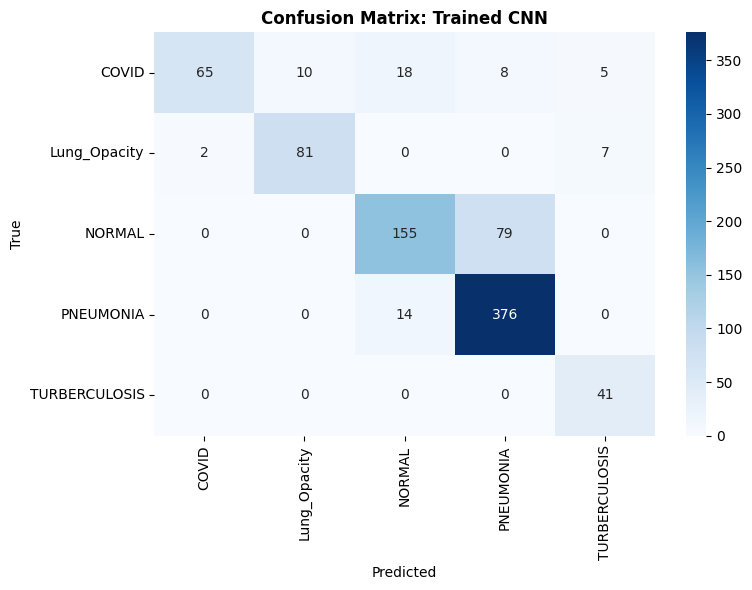

In [ ]:
plot_confusion_matrix(cnn_labels, cnn_preds, CLASS_NAMES,
                      'Confusion Matrix: Trained CNN',
                      'outputs/figures/9_trained_cnn_cm.png')

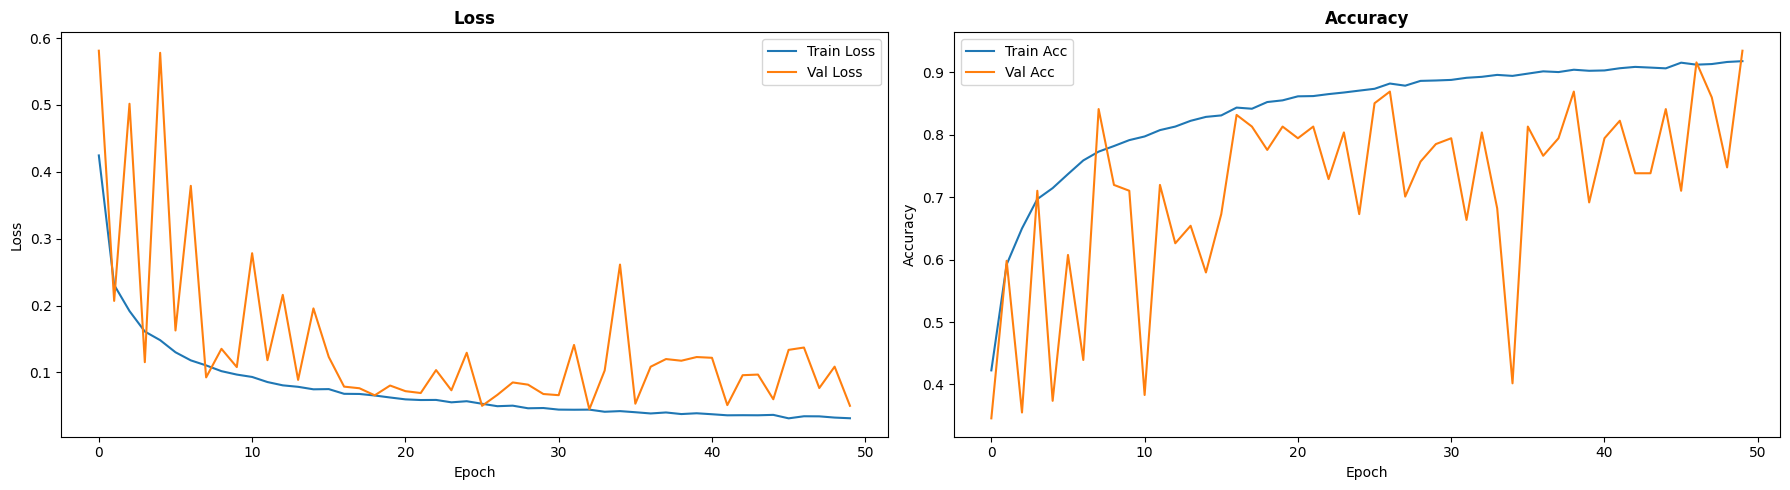

In [ ]:
# Plot training curves
def plot_training_curves(history, save_path):
    fig, axes = plt.subplots(1, 2, figsize=(18, 5))

    axes[0].plot(history.history['loss'],     label='Train Loss')
    axes[0].plot(history.history['val_loss'], label='Val Loss')
    axes[0].set_title('Loss', fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].legend()

    axes[1].plot(history.history['accuracy'],     label='Train Acc')
    axes[1].plot(history.history['val_accuracy'], label='Val Acc')
    axes[1].set_title('Accuracy', fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].legend()


    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

plot_training_curves(history, 'outputs/figures/7_training_curves.png')

In [ ]:
# Evaluate trained CNN on test set
cnn_preds, cnn_labels, cnn_probs, cnn_report, cnn_f1, cnn_auc = evaluate_model(
    model, test_ds, CLASS_NAMES
)

print('=== Trained CNN ===')
print(f'ROC-AUC  : {cnn_auc:.4f}')
print()
print(classification_report(cnn_labels, cnn_preds, target_names=CLASS_NAMES, zero_division=0))

=== Trained CNN ===
ROC-AUC  : 0.9821

               precision    recall  f1-score   support

        COVID       0.97      0.61      0.75       106
 Lung_Opacity       0.89      0.90      0.90        90
       NORMAL       0.83      0.66      0.74       234
    PNEUMONIA       0.81      0.96      0.88       390
TURBERCULOSIS       0.77      1.00      0.87        41

     accuracy                           0.83       861
    macro avg       0.85      0.83      0.83       861
 weighted avg       0.84      0.83      0.83       861

